# Demo: 2D image RI2FL

> 2D RI2FL demo


In [1]:
#| default_exp demo

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism
set_determinism(0)
# from sklearn.model_selection import train_test_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

In [5]:
bs, size = 8, 128
# arch = models.resnet34
# path = Path('../../bioMONAI_0/_data/Babesia/')
path = Path('../_data/Babesia/')
path_x = path/'RI'
path_y = path/'TRITC'

In [6]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC')(path / 'O11_RI_frame01.tiff')
image1 = torch.randn(256,256)
image2 = torch.randn(256,256)



def fourier_shell_correlation(image1, image2):

    # Transform tensor to complex
    image1 = image1.to(torch.complex64)
    image2 = image2.to(torch.complex64)


    # Numerator
    fft_image1 = torch.fft.fft2(image1)
    fft_image2 = torch.fft.fft2(image1)
    
    fft_image2_conj = fft_image2.conj()

    numerador = torch.sum(fft_image1 * fft_image2_conj)


    # Denominator
    

    denominador_1 = torch.sum(torch.abs(fft_image1) * torch.abs(fft_image1))

    denominador_2 = torch.sum(torch.abs(fft_image2) * torch.abs(fft_image2))

    denominador = torch.sqrt((denominador_1 * denominador_2))

    FSC = torch.div(numerador,denominador)

    return FSC



print(fourier_shell_correlation(image1,image2))






tensor(1.+0.j)


### Look at training data

In [12]:
from monai.transforms import ScaleIntensity

item_tfms = [ScaleIntensity(minv=0.0, maxv=1.0),
             RandCropND(size), 
             RandRot90(prob=0.5), 
             RandFlip(prob=0.75),
             ] 

Setting-up type transforms pipelines
Found 275 items
2 datasets of sizes 220,55
Setting up Pipeline: BioImageProject.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create

Building one sample
  Pipeline: BioImageProject.create
    starting from
      ../_data/Babesia/RI/O12_RI_frame30.tiff
    applying BioImageProject.create gives
      BioImageProject of size 1x512x512
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create
    starting from
      ../_data/Babesia/RI/O12_RI_frame30.tiff
    applying get_target.<locals>.generate_target_path gives
      ../_data/Babesia/TRITC/O12_TRITC_frame30.tiff
    applying BioImage.create gives
      BioImage of size 1x512x512

Final sample: (BioImage([[[135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.],
         ...,
         [135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ...,

Setting affine, but the applied meta contains an affine. This will be overwritten.


  Pipeline: ScaleIntensity -> RandCropND -- {'size': (128, 128, 128), 'lazy': False, 'p': 1.0} -> RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} -> RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} -> ToTensor
    starting from
      (BioImageProject of size 1x512x512, BioImage of size 1x512x512)
    applying ScaleIntensity gives
      (MetaTensor of size 1x512x512, MetaTensor of size 1x512x512)
    applying RandCropND -- {'size': (128, 128, 128), 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    applying RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    applying RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    app

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


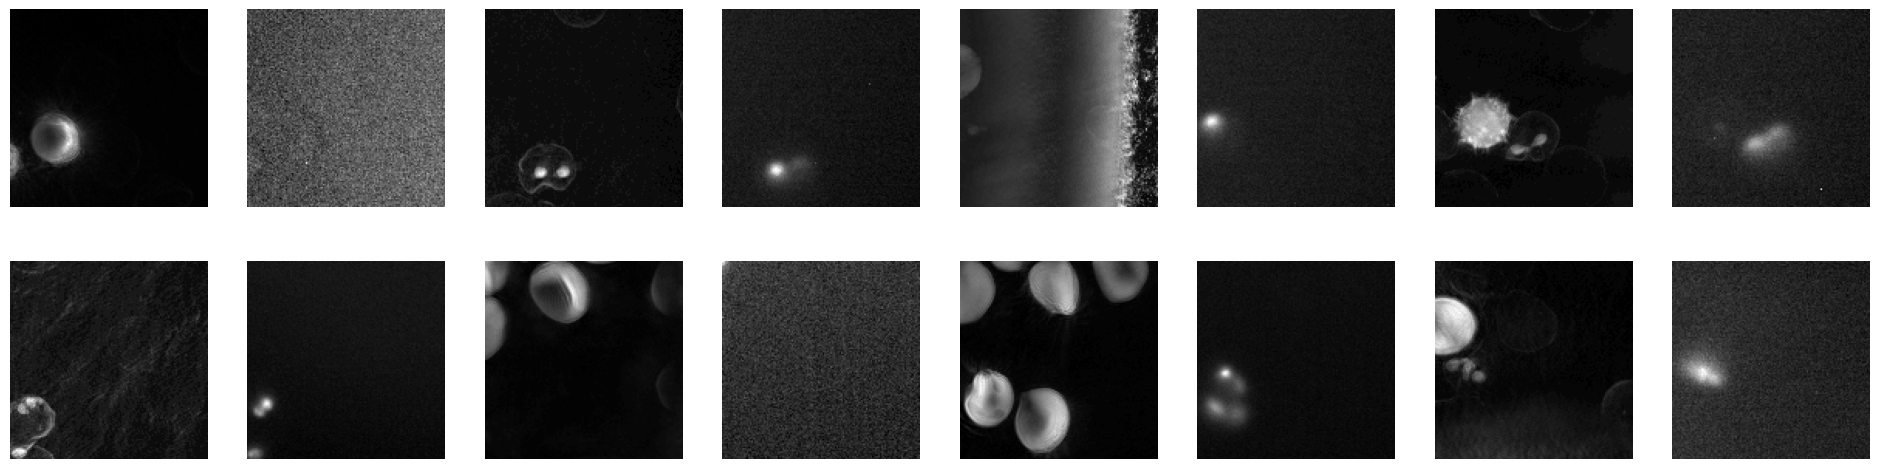

In [14]:

from bioMONAI.core import get_target

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )

dblock.summary(path_x)

dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')


In [ ]:
# training and validation
len(dls.train_ds.items), len(dls.valid_ds.items)

### Create and train a 2D model

In [ ]:
from monai.networks.nets import UNet # AttentionUnet, DynUNet, UNet, BasicUNet

In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
# model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)

In [ ]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

from monai.losses import MultiScaleLoss, SSIMLoss

loss_func = MultiScaleLoss(SSIMLoss)




In [ ]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [ ]:
# learn = Learner(dls, model, loss_func=loss_func, opt_func=ranger, metrics=nn.L1Loss)
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, cbs=ShowGraphCallback())

In [ ]:
learn.summary()

In [ ]:
# lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
lr = learn.lr_find(suggest_funcs=(valley))
print(lr)

In [ ]:
lr = float('%.1g'%(lr))
print(lr)

In [ ]:
learn.fit_flat_cos(20,lr)

In [ ]:
learn.show_results(cmap='gray')

In [ ]:
# learn.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [ ]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [ ]:
# learn.export('______.pkl')

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()